## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import beta, norm

## Part A: Titanic

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
target_group = df[(df['pclass'] == 3) & (df['sex'] == 'male')]['survived']
target_group.head()

0     0
4     0
5     0
7     0
12    0
Name: survived, dtype: int64

In [4]:
len(target_group), target_group.unique(), target_group.mean()

(347, array([0, 1]), np.float64(0.13544668587896252))

In [15]:
def bernoulli_likelihood(p, data):
    return np.prod(p**data * (1-p)**(1-data))

In [38]:
priors = [
    (5, 5),  # Lucky
    (2, 20), # Low theta
    (1, 1),  # Uniform prior
]

In [39]:
target_group50 = target_group[:10]
survivors = np.sum(target_group50 == 1)
deaths = np.sum(target_group50 == 0)

print(survivors, deaths)

1 9


In [52]:
p_values = np.linspace(0, 1, 100)

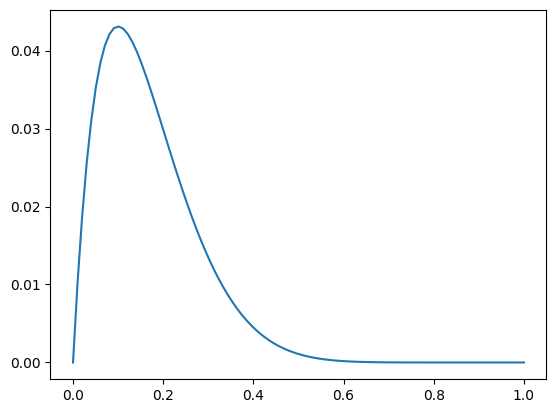

In [104]:
likelihood = np.vectorize(lambda x: bernoulli_likelihood(x, target_group50))(p_values)
plt.plot(p_values, likelihood / np.sum(likelihood), label='Likelihood')

Mean with Prior (5, 5): 0.11493808049499137
Mean with Prior (2, 20): 0.28907473148324797
Mean with Prior (1, 1): 0.1499999227392841


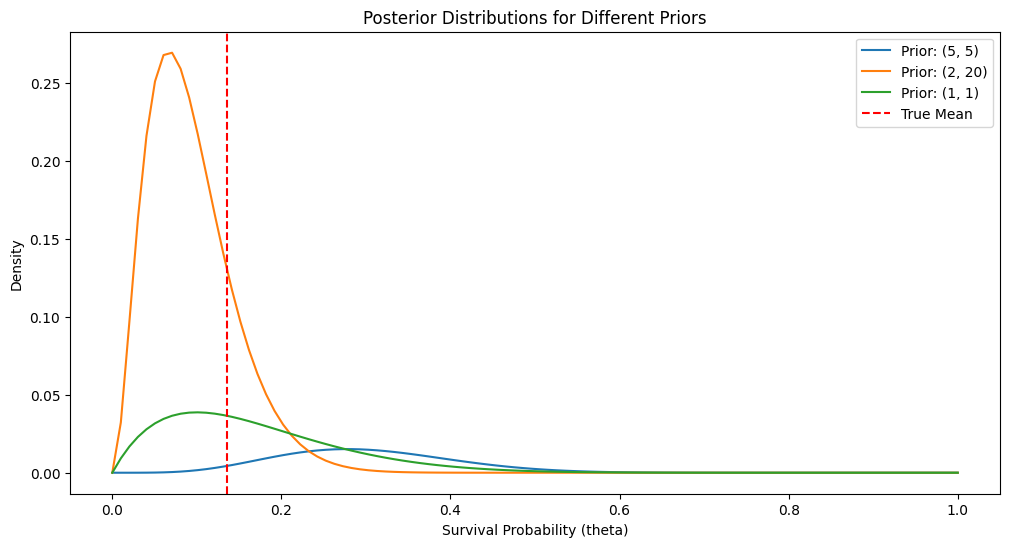

In [127]:
plt.figure(figsize=(12, 6))

for a, b in priors:
    posterior = beta.pdf(p_values, a, b) * likelihood
    # posterior /= np.sum(posterior)  # Normalize
    plt.plot(p_values, posterior, label=f'Prior: ({a}, {b})')
    print(f"Mean with Prior ({a}, {b}):", np.sum(p_values * posterior))

plt.axvline(target_group.mean(), color='r', linestyle='--', label='True Mean')
plt.title('Posterior Distributions for Different Priors')
plt.xlabel('Survival Probability (theta)')
plt.ylabel('Density')
plt.legend()
plt.show()

#### In class

In [116]:
def get_posterior_weights(theta_samples):
    likelihood = np.vectorize(lambda x: bernoulli_likelihood(x, target_group50))(theta_samples)
    return likelihood / np.sum(likelihood)

N = 1_00_000

Mean with Beta Prior: 0.3000905674553753


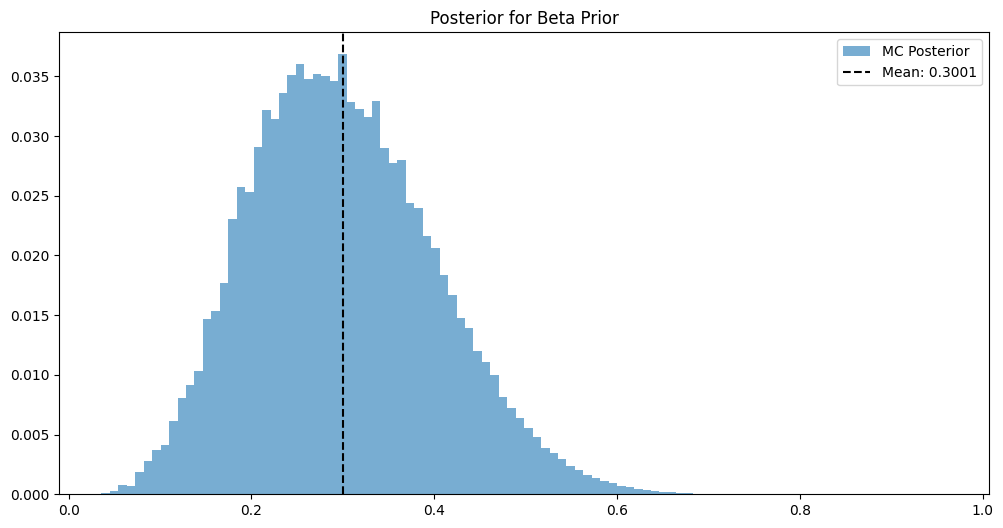

In [131]:
# Beta Prior
theta_samples = np.random.beta(5, 5, N)
weights = get_posterior_weights(theta_samples)
mean_beta = np.sum(theta_samples * weights)
print("Mean with Beta Prior:", mean_beta)

plt.figure(figsize=(12, 6))
plt.hist(theta_samples, weights=weights, bins=100, alpha=0.6, label='MC Posterior')
# for a, b in [(5, 5)]:
#     posterior = beta.pdf(p_values, a, b) * likelihood
#     posterior /= np.sum(posterior)  # Normalize
#     plt.plot(p_values, posterior, label=f'Prior: ({a}, {b})')
plt.axvline(mean_beta, color='k', linestyle='--', label=f'Mean: {mean_beta:.4f}')
plt.title(r'Posterior for Beta Prior')
plt.legend()
plt.show()

Mean with sin Prior: 0.21946720143961632


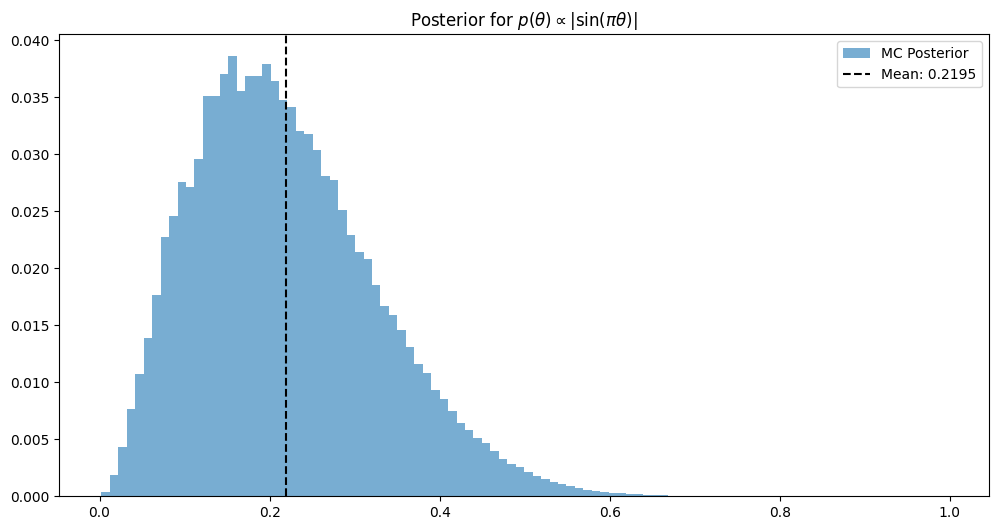

In [129]:
# Beta Prior
uni_samples = np.random.uniform(0, 1, N)
theta_samples = (1/np.pi) * np.arccos(1 - 2*uni_samples)
weights = get_posterior_weights(theta_samples)
mean_beta = np.sum(theta_samples * weights)
print("Mean with sin Prior:", mean_beta)

plt.figure(figsize=(12, 6))
plt.hist(theta_samples, weights=weights, bins=100, alpha=0.6, label='MC Posterior')
plt.axvline(mean_beta, color='k', linestyle='--', label=f'Mean: {mean_beta:.4f}')
plt.title(r'Posterior for $p(\theta) \propto |\sin(\pi\theta)|$')
plt.legend()
plt.show()

Mean with sin Prior: 0.14438145816449013


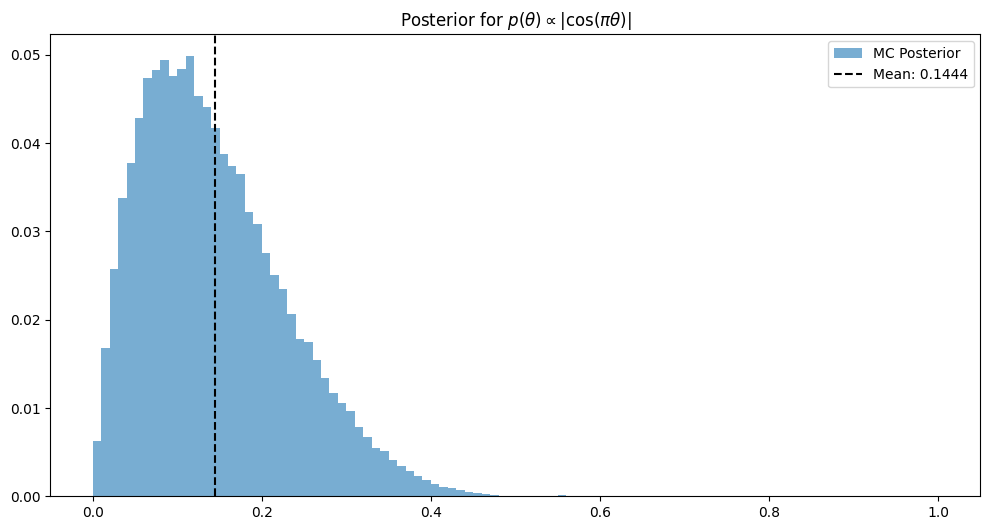

In [125]:
# Beta Prior
u = np.random.uniform(0, 1, N)
theta_samples = np.where(
    u <= 0.5,
    (1/np.pi) * np.arcsin(np.clip(2*u, -1, 1)),
    1 + (1/np.pi) * np.arcsin(np.clip(2*u - 2, -1, 1))
)
weights = get_posterior_weights(theta_samples)
mean_beta = np.sum(theta_samples * weights)
print("Mean with sin Prior:", mean_beta)

plt.figure(figsize=(12, 6))
plt.hist(theta_samples, weights=weights, bins=100, alpha=0.6, label='MC Posterior')
plt.axvline(mean_beta, color='k', linestyle='--', label=f'Mean: {mean_beta:.4f}')
plt.title(r'Posterior for $p(\theta) \propto |\cos(\pi\theta)|$')
plt.legend()
plt.show()

Mean with Uniform Prior: 0.16728641824745583


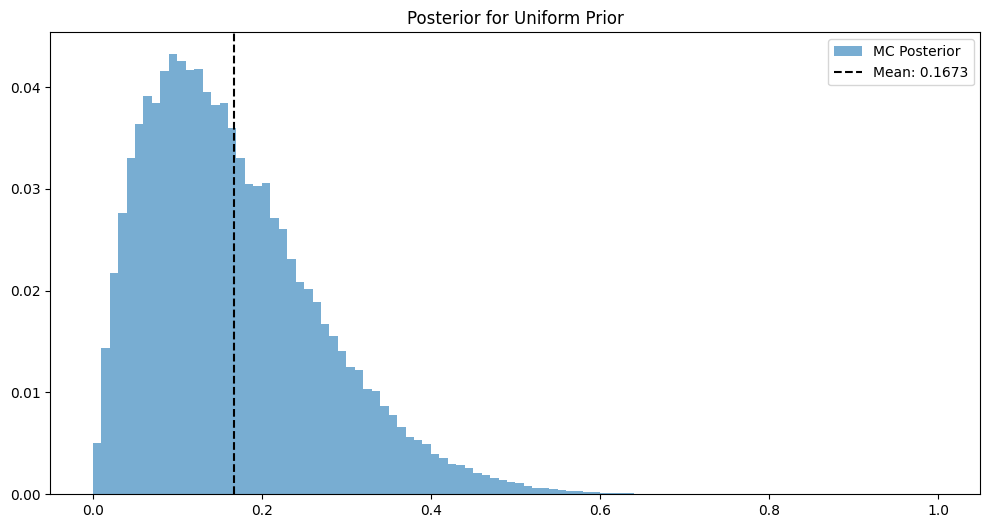

In [130]:
# Beta Prior
u = np.random.uniform(0, 1, N)
theta_samples = u
weights = get_posterior_weights(theta_samples)
mean_beta = np.sum(theta_samples * weights)
print("Mean with Uniform Prior:", mean_beta)

plt.figure(figsize=(12, 6))
plt.hist(theta_samples, weights=weights, bins=100, alpha=0.6, label='MC Posterior')
plt.axvline(mean_beta, color='k', linestyle='--', label=f'Mean: {mean_beta:.4f}')
plt.title(r'Posterior for Uniform Prior')
plt.legend()
plt.show()

## Part B: Speed of Light

In [ ]:
light = pd.read_csv('./data/light.csv')
light.head()

,rownames,Expt,Run,Speed
0,1,1,1,850
1,2,1,2,740
2,3,1,3,900
3,4,1,4,1070
4,5,1,5,930


In [71]:
light['Speed'].mean(), light['Speed'].var(ddof=1)

(np.float64(852.4), np.float64(6242.666666666667))

In [84]:
mu_values = np.linspace(light['Speed'].min(), light['Speed'].max(), 100)

def get_likelihood(data):
    return [np.prod(norm.pdf(data, loc=mu, scale=100)) for mu in mu_values]

In [ ]:
like = get_likelihood(light['Speed'][:5])
np.sum(mu_values * like / np.sum(like))

np.float64(897.9910606889468)

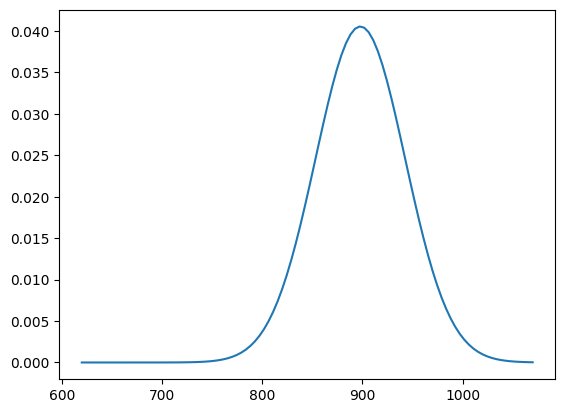

In [95]:
plt.plot(mu_values, like / np.sum(like), label='Likelihood')

In [100]:
datasets = {
    'n5': light['Speed'][:5],
    'n50': light['Speed'][:50],
    'n100': light['Speed'][:100],
}

In [101]:
for name, data in datasets.items():
    likelihood = get_likelihood(data)
    posterior = likelihood * norm.pdf(mu_values, loc=700, scale=50)
    posterior /= np.sum(posterior)  # Normalize
    
    mean = np.sum(mu_values * posterior)
    variance = np.sum(((mu_values - mean)**2) * posterior)
    print("Mean:", mean, "Variance:", variance)

Mean: 810.000000772776 Variance: 1111.1109622986407
Mean: 860.0 Variance: 185.18518518518505
Mean: 846.5384615384615 Variance: 96.1538461538461


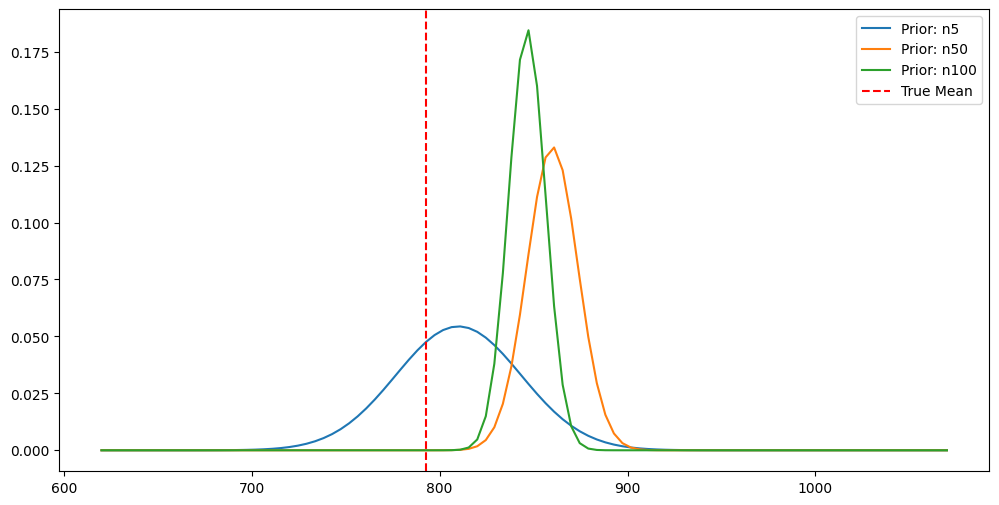

In [102]:
plt.figure(figsize=(12, 6))

for name, data in datasets.items():
    likelihood = get_likelihood(data)
    posterior = likelihood * norm.pdf(mu_values, loc=700, scale=50)
    posterior /= np.sum(posterior)  # Normalize
    
    plt.plot(mu_values, posterior, label=f'Prior: {name}')

plt.axvline(792.458, color='r', linestyle='--', label='True Mean')
plt.legend()
plt.show()